## Adaptive RAG

**Adaptive RAG** is a Retrieval-Augmented Generation (RAG) strategy that combines **(1) query analysis** with **(2) active/self-corrective retrieval** to dynamically adapt how information is retrieved and used.

According to the [paper](https://arxiv.org/pdf/2403.14403), Adaptive RAG performs **query analysis** to determine the most suitable retrieval strategy among the following:

* **No Retrieval** – for straightforward queries that can be answered directly by the model.
* **Single-shot RAG** – for simple queries that require one round of retrieval.
* **Iterative RAG** – for complex queries that need multiple retrieval and reasoning iterations.



---

## Implementing Adaptive RAG with **LangGraph**

In our **Adaptive RAG** approach using **LangGraph**, we design a **dynamic routing mechanism** that decides which retrieval strategy to use based on the nature of the user’s query.

Our routing will switch between two main paths:

* **Web Search** – Used for questions related to **recent or real-world events**, where up-to-date information is required.
* **Self-Corrective RAG** – Used for questions related to **our existing knowledge index**, where the system can iteratively retrieve, reason, and refine its responses to ensure accuracy.

This hybrid routing enables the system to **adapt retrieval behavior at runtime**, improving both **relevance** (for current data) and **depth** (for indexed knowledge).

---







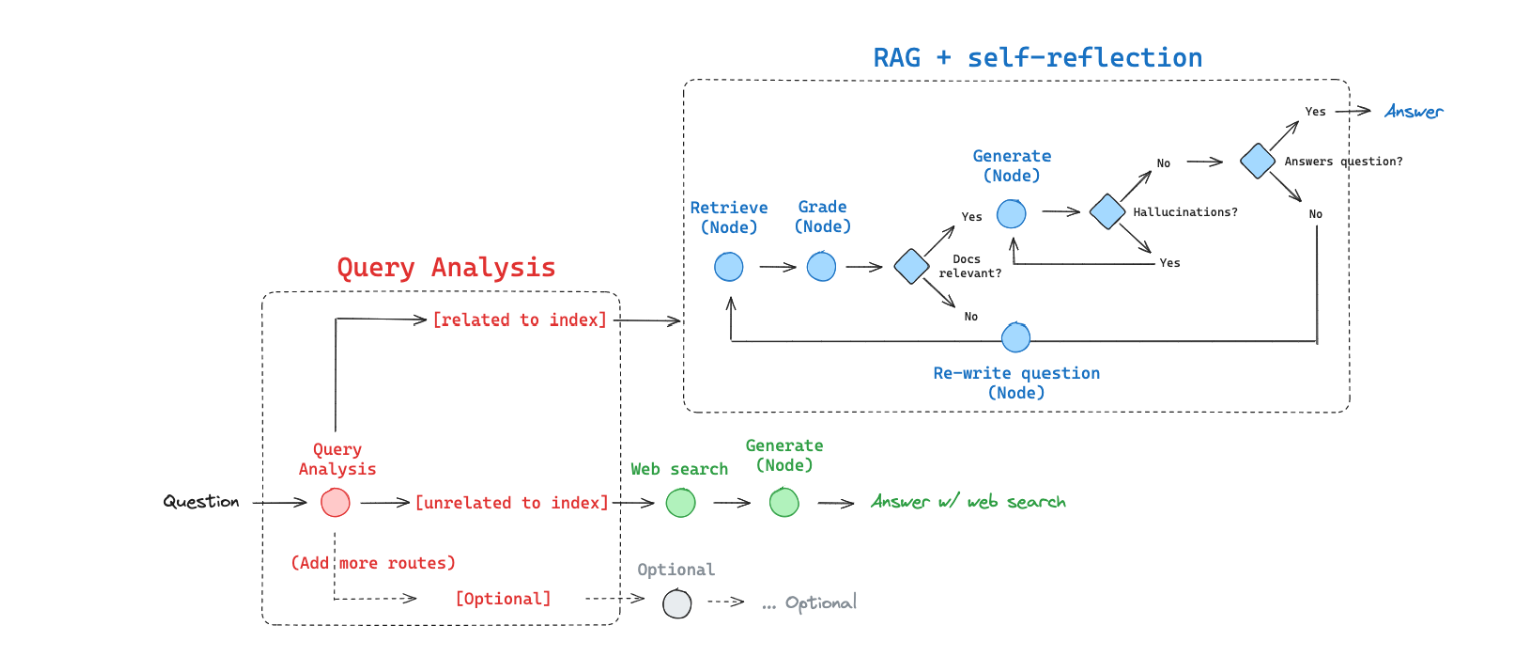

In [1]:
# for snaps
from IPython.display import Image, display
display(Image("/content/Screenshot 2025-10-08 111454.png"))

#Enviornment setup:

In [2]:
%%capture
! pip install -U langchain_community tiktoken langchain-groq langchain-cohere langchainhub chromadb langchain langgraph  tavily-python

##Tracing
* Optionally, use LangSmith for tracing (shown at bottom) by setting:

In [ ]:
from google.colab import userdata
import os
try:

  # Set LangSmith environment variables
  os.environ["LANGSMITH_API_KEY"] = userdata.get("LANGSMITH_API_KEY")
  os.environ["LANGCHAIN_TRACING_V2"] = "true"
  os.environ["LANGCHAIN_PROJECT"] = "Adaptive RAG Agent notebook"

  # Optional: Set LangSmith endpoint (usually not needed)
  # os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"

  # Verify setup
  print("LangSmith tracing enabled for project:", os.environ.get("LANGCHAIN_PROJECT"))

except Exception as e:
  print(f"Error setting up LangSmith tracing: {e}")

LangSmith tracing enabled for project: Adaptive RAG Agent notebook


In [ ]:
### LLMs and APIs

# impors
# set all the required api keys in your colab secrets then load into notebook by this code:
# Get API key from Colab secrets
import os
from google.colab import userdata

try:
    from google.colab import userdata
    os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')
    print("GROQ API key loaded successfully!")

    os.environ['COHERE_API_KEY'] = userdata.get("COHERE_API_KEY")
    print("COHERE API key loaded successfully!")

    os.environ['TAVILY_API_KEY'] = userdata.get("TAVILY_API_KEY")
    print("TAVILY API key loaded successfully!")

    print("All API keys loaded successfully!")
except Exception as e:
    print(f"Error loading API key: {e}")
    print("Please add your GROQ_API_KEY to Colab secrets (🔑 icon in left sidebar)")

GROQ API key loaded successfully!
COHERE API key loaded successfully!
TAVILY API key loaded successfully!
All API keys loaded successfully!


## Index

In [ ]:
# Indexing

from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import SentenceTransformerEmbeddings

urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=1000, chunk_overlap=200
)
doc_splits = text_splitter.split_documents(docs_list)

# Add to vectorDB
vectorstore = Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chroma",
    embedding=SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2"),
)
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 8}  # Get more chunks
)

/tmp/ipython-input-2470506213.py:26: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embedding=SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2"),
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  war

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Check new chunk sizes
print(f"Total chunks: {len(doc_splits)}")
print(f"Average chunk length: {sum(len(chunk.page_content) for chunk in doc_splits) / len(doc_splits)}")

# Test retrieval
test_docs = retriever.get_relevant_documents("types of agent memory")

for i, doc in enumerate(test_docs[:3]):
    print(f"\nRetrieved Doc {i}:")
    print(doc.page_content[:500])

Total chunks: 47
Average chunk length: 2961.808510638298

Retrieved Doc 0:
Memory

Short-term memory: I would consider all the in-context learning (See Prompt Engineering) as utilizing short-term memory of the model to learn.
Long-term memory: This provides the agent with the capability to retain and recall (infinite) information over extended periods, often by leveraging an external vector store and fast retrieval.


Tool use

The agent learns to call external APIs for extra information that is missing from the model weights (often hard to change after pre-training), 

Retrieved Doc 1:
LLM Powered Autonomous Agents | Lil'Log







































Lil'Log

















|






Posts




Archive




Search




Tags




FAQ









      LLM Powered Autonomous Agents
    
Date: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng


 


Table of Contents



Agent System Overview

Component One: Planning

Task Decomposition

Self-Reflection


Compon

/tmp/ipython-input-4126657045.py:6: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  test_docs = retriever.get_relevant_documents("types of agent memory")


##LLMs

In [3]:
# Router
from typing import Literal
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.pydantic_v1 import BaseModel, Field
from langchain_groq import ChatGroq

# data model
class RouterQuery(BaseModel):
  """ Route a user to the most relevant datasource. """

  datasource: Literal["vectorstore", "web_search"] = Field( ..., description="Given a user query, route to the most relevant datasource.")

# LLM with function call
llm = ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct", temperature=0)
structured_llm_router = llm.with_structured_output(RouterQuery)


# prompts
system = """You are an expert at routing a user question to a vectorstore or web search.
The vectorstore contains documents related to agents, prompt engineering, and adversarial attacks.
Use the vectorstore for questions on these topics. Otherwise, use web-search.
"""
route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),

    ]
)

question_router = route_prompt | structured_llm_router
print(question_router.invoke({"question": "Who will the Bears draft first in the NFL draft?"}))
print(question_router.invoke({"question": "What are the types of agent memory?"}))

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3553: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  exec(code_obj, self.user_global_ns, self.user_ns)


GroqError: The api_key client option must be set either by passing api_key to the client or by setting the GROQ_API_KEY environment variable

In [ ]:
### Retrieval Grader

# Data model
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(description="Documents are relevant to the question, 'yes' or 'no'")

# LLM with function call
llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question. \n
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

retrieval_grader = grade_prompt | structured_llm_grader
question = "agent memory"
docs = retriever.get_relevant_documents(question)
doc_txt = docs[1].page_content
print(retrieval_grader.invoke({"question": question, "document": doc_txt}))

binary_score='yes'


In [ ]:
### Generate

from langchain import hub
from langchain_core.output_parsers import StrOutputParser

# Prompt
prompt = hub.pull("rlm/rag-prompt")

# LLM
llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct", temperature=0)

# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# Chain
rag_chain = prompt | llm | StrOutputParser()

# Run
generation = rag_chain.invoke({"context": docs, "question": question})
print(generation)

In a LLM-powered autonomous agent system, the agent's memory can be categorized into short-term memory and long-term memory. Short-term memory refers to the in-context learning of the model to learn, which is restricted by the finite context window length of Transformer. Long-term memory provides the agent with the capability to retain and recall infinite information over extended periods, often by leveraging an external vector store and fast retrieval.


In [ ]:
### Hallucination Grader

# Data model
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeHallucinations)

# Prompt
system = """You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved facts. \n
     Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the set of facts."""

hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
    ]
)

hallucination_grader = hallucination_prompt | structured_llm_grader
hallucination_grader.invoke({"documents": docs, "generation": generation})

GradeHallucinations(binary_score='yes')

In [ ]:
### Answer Grader

# Data model
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeAnswer)

# Prompt
system = """You are a grader assessing whether an answer addresses / resolves a question \n
     Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question."""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
    ]
)

answer_grader = answer_prompt | structured_llm_grader
answer_grader.invoke({"question": question, "generation": generation})

GradeAnswer(binary_score='yes')

In [ ]:
### Question Re-writer

# LLM
llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")

# Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized \n
     for vectorstore retrieval. Look at the input and try to reason about the underlying sematic intent / meaning."""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Here is the initial question: \n\n {question} \n Formulate an improved question."),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser() | (lambda x: print(x))
question_rewriter.invoke({"question": question})

After analyzing the input question "agent memory", I've formulated an improved question that's optimized for vectorstore retrieval:

"What are the capabilities and limitations of an agent's memory in artificial intelligence systems?"

Here's my reasoning:

1. **Clarifying the context**: The original question is quite vague. By adding "in artificial intelligence systems", I'm specifying the context to help the vectorstore retrieval system focus on relevant information.
2. **Expanding the semantic scope**: The original question only mentions "agent memory". By rephrasing it to "capabilities and limitations", I'm encouraging the retrieval system to return more comprehensive and informative results that cover various aspects of agent memory.
3. **Improving specificity and precision**: The improved question is more specific and precise, which can help the vectorstore retrieval system to better understand the user's intent and return more accurate results.

The improved question should help 

##Wb Search Tool

In [ ]:
from langchain_community.tools.tavily_search import TavilySearchResults
web_search_tool = TavilySearchResults(k=3)

/tmp/ipython-input-2239647488.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(k=3)


##Graph
Capture the flow in as a graph

##Graph state

In [ ]:
from typing_extensions import TypedDict
from typing import List

class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        documents: list of documents
    """
    question : str
    generation : str
    documents : List[str]

##Graph Flow

In [ ]:
from langchain.schema import Document

def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]

    # Retrieval
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}

In [ ]:
def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}

In [ ]:
def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    for d in documents:
        score = retrieval_grader.invoke({"question": question, "document": d.page_content})
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            continue
    return {"documents": filtered_docs, "question": question}

In [ ]:
def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}

In [ ]:
def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    print("---WEB SEARCH---")
    question = state["question"]

    # Web search
    docs = web_search_tool.invoke({"query": question})
    web_results = "\n".join([d["content"] for d in docs])
    web_results = Document(page_content=web_results)

    return {"documents": web_results, "question": question}

In [ ]:
### Edges ###

def route_question(state):
    """
    Route question to web search or RAG.

    Args:
        state (dict): The current graph state

    Returns:
        str: Next node to call
    """

    print("---ROUTE QUESTION---")
    question = state["question"]
    source = question_router.invoke({"question": question})
    if source.datasource == 'web_search':
        print("---ROUTE QUESTION TO WEB SEARCH---")
        return "web_search"
    elif source.datasource == 'vectorstore':
        print("---ROUTE QUESTION TO RAG---")
        return "vectorstore"

In [ ]:
def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    question = state["question"]
    filtered_documents = state["documents"]

    if not filtered_documents:
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print("---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---")
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"

In [ ]:
def grade_generation_v_documents_and_question(state):
    """
    Determines whether the generation is grounded in the document and answers question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Decision for next node to call
    """

    print("---CHECK HALLUCINATIONS---")
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]

    score = hallucination_grader.invoke({"documents": documents, "generation": generation})
    grade = score.binary_score

    # Check hallucination
    if grade == "yes":
        print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")
        # Check question-answering
        print("---GRADE GENERATION vs QUESTION---")
        score = answer_grader.invoke({"question": question,"generation": generation})
        grade = score.binary_score
        if grade == "yes":
            print("---DECISION: GENERATION ADDRESSES QUESTION---")
            return "useful"
        else:
            print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
            return "not useful"
    else:
        pprint("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---")
        return "not supported"

##Build Graph



In [ ]:
from langgraph.graph import END, StateGraph

workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("web_search", web_search) # web search
workflow.add_node("retrieve", retrieve) # retrieve
workflow.add_node("grade_documents", grade_documents) # grade documents
workflow.add_node("generate", generate) # generatae
workflow.add_node("transform_query", transform_query) # transform_query

# Build graph
workflow.set_conditional_entry_point(
    route_question,
    {
        "web_search": "web_search",
        "vectorstore": "retrieve",
    },
)
workflow.add_edge("web_search", "generate")
workflow.add_edge("retrieve", "grade_documents")

workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "retrieve")
workflow.add_conditional_edges(
    "generate",
    grade_generation_v_documents_and_question,
    {
        "not supported": "generate",
        "useful": END,
        "not useful": "transform_query",
    },
)

# Compile
app = workflow.compile()

In [ ]:
from pprint import pprint

# Run
inputs = {"question": "What player at the Bears expected to draft first in the 2024 NFL draft?"}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")

# Final generation
pprint(value["generation"])

---ROUTE QUESTION---
---ROUTE QUESTION TO WEB SEARCH---
---WEB SEARCH---
"Node 'web_search':"
'\n---\n'
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---
"Node 'generate':"
'\n---\n'
('The Chicago Bears expected to draft Caleb Williams first in the 2024 NFL '
 'draft. He was selected as the first overall pick. Some people, however, '
 'believe Jayden Daniels would have been a better choice.')


Trace:
https://smith.langchain.com/public/ced73229-5fa1-4d4d-87b0-b8a881d69630/r

In [ ]:
# Run
inputs = {"question": "What are the types of agent memory?"}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")

# Final generation
pprint(value ["generation"])

---ROUTE QUESTION---
---ROUTE QUESTION TO RAG---
---RETRIEVE---
"Node 'retrieve':"
'\n---\n'
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE---
"Node 'grade_documents':"
'\n---\n'
---GENERATE---
---CHECK HALLUCINATIONS---


Trace:
https://smith.langchain.com/public/007dd15c-8294-4dd1-bd15-163001eb2e2d/r